In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated,List
from dotenv import load_dotenv
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import HumanMessage, AIMessage
from pydantic import BaseModel, Field
import os
import operator 

In [2]:
load_dotenv()

MISTRAL_API_KEY = os.getenv("MISTRAL_API_KEY")

if MISTRAL_API_KEY is None:
    raise ValueError("MISTRAL_API_KEY environment variable not set")

In [3]:
llm = ChatMistralAI(
    model_name = "open-mistral-nemo",
    temperature=0.7,
    max_tokens=1024,
    api_key=os.environ["MISTRAL_API_KEY"] 
)

response = llm.invoke([HumanMessage(content="what is the capital of india?\n")])
print(response.content)

The capital of India is New Delhi. It's the largest commercial city in northern India and an important cultural, political, and historical center of the country. New Delhi was established in 1911 and officially became the capital of India in 1947, when the country gained independence from British rule. Before New Delhi, the capital of British India was Calcutta (now Kolkata), and later, it was shifted to Delhi in 1911.


In [4]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback for the essay")
    score: int = Field(description="Score out of 10",ge=0,le=10)

In [5]:
structured_model = llm.with_structured_output(EvaluationSchema)

In [6]:
essay = """Adolf Hitler (1889-1945) stands as one of the most infamous and consequential figures in modern history. As the dictator of Nazi Germany from 1933 to 1945, he was the mastermind behind World War II and the Holocaust, events that caused unprecedented suffering and reshaped the global order . His life is a chilling study of how a combination of personal ideology, political opportunism, and social chaos can lead to unimaginable catastrophe.

Hitler's early life gave little indication of his future infamy. Born in Austria in 1889, he was a failed artist who spent his younger years in poverty in Vienna . It was in the Austrian capital that he cultivated a deep contempt for democracy and a virulent form of racism and anti-Semitism, influenced by the city's populist mayor . The outbreak of World War I in 1914 provided him with a sense of purpose; he volunteered for the German army and served with distinction, earning medals for bravery . Germany's defeat in 1918 radicalized him, as he bitterly believed the army had been "stabbed in the back" by civilian politicians and internal enemies .

After the war, Hitler's life found its political direction. In 1919, he joined a tiny nationalist group in Munich, the German Workers' Party, and soon became its leading propagandist and leader . He rebranded it as the National Socialist German Workers' Party (NSDAP), or Nazi Party, and discovered his extraordinary talent for public speaking . An early attempt to seize power violently, the 1923 "Beer Hall Putsch," failed and landed him in prison. However, he used his trial to gain national attention and his subsequent incarceration to write *Mein Kampf* ("My Struggle"), a book outlining his racist ideology and his plans for a greater Germany .

Upon his release, Hitler adopted a new strategy: he would destroy the Weimar Republic from within by using its own democratic system. The Great Depression, which plunged Germany into economic ruin and mass unemployment, created the perfect opportunity for the Nazis to rise . Hitler promised desperate Germans a return to greatness, scapegoating Jews, communists, and the Treaty of Versailles for the nation's problems . Through a combination of propaganda, intimidation by his paramilitary forces (the SA), and promises to the traditional elite, the Nazi Party became the largest in parliament . In January 1933, President Paul von Hindenburg, believing he could control him, appointed Hitler as Chancellor .

Once in power, Hitler acted with terrifying speed to become an absolute dictator. Using the Reichstag fire as a pretext, he convinced Hindenburg to sign an emergency decree that suspended civil liberties . He then pushed through the Enabling Act, which gave him the power to make laws without parliament's consent . When Hindenburg died in 1934, Hitler merged the offices of president and chancellor, declaring himself **Führer** (Leader) of Germany . All soldiers and civil servants swore a personal oath of loyalty to him .

As Führer, Hitler began implementing his ideological goals. Domestically, he unleashed a wave of terror against his political opponents and, with increasing severity, against German Jews. The Nuremberg Laws of 1935 stripped Jews of their citizenship and rights, laying the groundwork for the Holocaust . Aggressively, he set out to overturn the Treaty of Versailles and expand German territory, remilitarizing the Rhineland, annexing Austria and Czechoslovakia, and culminating in the invasion of Poland on September 1, 1939, which ignited World War II .

The war became the vehicle for Hitler's most horrific crime: the systematic, state-sponsored genocide of six million Jews and millions of others, including Slavs, Roma, and disabled people, in what we now call the Holocaust . His quest for *Lebensraum* (living space) in the East led to a brutal war of annihilation against the Soviet Union .

Ultimately, Hitler's megalomania and strategic errors led to Germany's defeat. As the Soviet army closed in on Berlin in April 1945, with his dream of a thousand-year Reich in ruins, Hitler committed suicide in his bunker . He left behind a continent in ruins and a legacy of evil that serves as a permanent warning about the dangers of hatred, totalitarianism, and the abdication of democratic responsibility."""

In [7]:
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}'
structured_model.invoke(prompt)

EvaluationSchema(feedback="The essay provides a comprehensive overview of Hitler's life and the consequences of his actions. It is well-researched and presents a clear narrative. However, there are some grammatical errors and awkward phrasing that could be improved. For example, 'It was in the Austrian capital that he cultivated a deep contempt for democracy' could be rephrased for better flow. Additionally, some sentences are too long and could be broken up for better readability. Overall, the essay is informative and engaging, but there is room for improvement in terms of language use and style.", score=7)

In [8]:
# create a graph and its states
class EssayEvaluationState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [21]:
def evaluate_language(state: EssayEvaluationState):
    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \\n {state["essay"]}'
    output = structured_model.invoke(prompt)
    return {"language_feedback": output.feedback, "individual_scores": [output.score]}

def evaluate_analysis(state: EssayEvaluationState):
    prompt = f'Evaluate the analysis quality of the following essay and provide a feedback and assign a score out of 10 \\n {state["essay"]}'
    output = structured_model.invoke(prompt)
    return {"analysis_feedback": output.feedback, "individual_scores": [output.score]}

def evaluate_clarity(state: EssayEvaluationState):
    prompt = f'Evaluate the clarity of the following essay and provide a feedback and assign a score out of 10 \\n {state["essay"]}'
    output = structured_model.invoke(prompt)
    return {"clarity_feedback": output.feedback, "individual_scores": [output.score]}

In [22]:
def generate_overall_feedback(state: EssayEvaluationState):

    prompt = f'Based on the following feedback and scores, generate an overall feedback for the essay and assign an overall score out of 10 \n Language Feedback: {state["language_feedback"]} \n Analysis Feedback: {state["analysis_feedback"]} \n Clarity Feedback: {state["clarity_feedback"]} \n Individual Scores: {state["individual_scores"]}'
    output = llm.invoke(prompt)
    
    # calculate average score
    avg_score = sum(state["individual_scores"])/len(state["individual_scores"])

    return {"overall_feedback": output.content, "avg_score": avg_score}

In [23]:
# defining graph
graph = StateGraph(EssayEvaluationState)

# add graph nodes
graph.add_node("evaluate_language", evaluate_language)
graph.add_node("evaluate_analysis", evaluate_analysis)
graph.add_node("evaluate_clarity", evaluate_clarity)
graph.add_node("generate_overall_feedback", generate_overall_feedback)

# add graph edges
graph.add_edge(START, "evaluate_language")
graph.add_edge(START, "evaluate_analysis")
graph.add_edge(START, "evaluate_clarity")
graph.add_edge("evaluate_language", "generate_overall_feedback")
graph.add_edge("evaluate_analysis", "generate_overall_feedback")    
graph.add_edge("evaluate_clarity", "generate_overall_feedback")
graph.add_edge("generate_overall_feedback", END)

workflow = graph.compile()

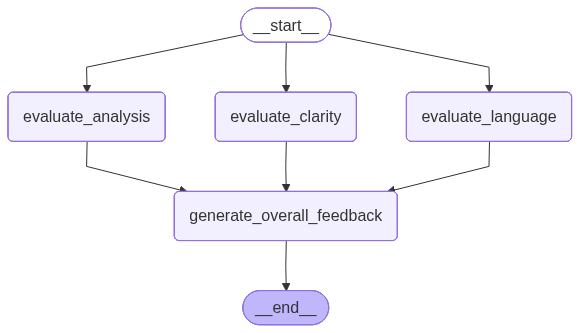

In [ ]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [26]:
initial_state = {
    "essay": essay,
    "language_feedback": "",
    "analysis_feedback": "",
    "clarity_feedback": "",
    "individual_scores": []
}

workflow.invoke(initial_state)

{'essay': 'Adolf Hitler (1889-1945) stands as one of the most infamous and consequential figures in modern history. As the dictator of Nazi Germany from 1933 to 1945, he was the mastermind behind World War II and the Holocaust, events that caused unprecedented suffering and reshaped the global order . His life is a chilling study of how a combination of personal ideology, political opportunism, and social chaos can lead to unimaginable catastrophe.\n\nHitler\'s early life gave little indication of his future infamy. Born in Austria in 1889, he was a failed artist who spent his younger years in poverty in Vienna . It was in the Austrian capital that he cultivated a deep contempt for democracy and a virulent form of racism and anti-Semitism, influenced by the city\'s populist mayor . The outbreak of World War I in 1914 provided him with a sense of purpose; he volunteered for the German army and served with distinction, earning medals for bravery . Germany\'s defeat in 1918 radicalized hi